# Phishing or Malicious URL Detector using Structured Machine Learning

## Step 1: Imports and setup

In [5]:
import os
import re
import math
import json
import unicodedata
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb

from urllib.parse import urlparse, unquote
import idna

from sklearn.model_selection import StratifiedKFold, GroupKFold, StratifiedGroupKFold, train_test_split
from sklearn.metrics import roc_auc_score, average_precision_score, precision_recall_fscore_support, classification_report
from sklearn.metrics import precision_recall_curve, roc_curve
from sklearn.preprocessing import StandardScaler
from sklearn.calibration import CalibratedClassifierCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin

import joblib

## Step 2: Loading and normalizing the dataset

In [6]:
CSV_PATH = "websites_dataset.csv"  
df = pd.read_csv(CSV_PATH, header=None, names=["domain", "label"])

# Drop empty domain, normalize labels to int {0,1}
df = df.dropna(subset=["domain"])
df["label"] = pd.to_numeric(df["label"], errors="coerce")
df = df.dropna(subset=["label"])
df["label"] = (df["label"] > 0).astype(int)


print(df.head(10))
print(df["label"].value_counts())
print(f"Rows: {len(df)}")


                                               domain  label
1   http://sprint.com/business/solutions/mobility_...      0
2               hesperia.gsfc.nasa.gov/~schmahl/nnls/      0
3   http://web.de/magazine/digital/sicher-im-netz/...      0
4   www.wired.com/science/discoveries/news/1999/08...      0
5    thomas.arnatt.com/wp-includes/pono/AOL_Logio.htm      1
6   http://elitedaily.com/women/fashion-blogger-co...      0
7                     www.siam.org/meetings/alenex03/      0
8   http://otomoto.pl/oferta/kobelco-sk35sr-3-mini...      0
9                                          pt21na.com      0
10                        www.physicalbits.com/Xtras/      0
label
0    92680
1    28310
Name: count, dtype: int64
Rows: 120990


# Step 3: Exploratory Data Anaylsis

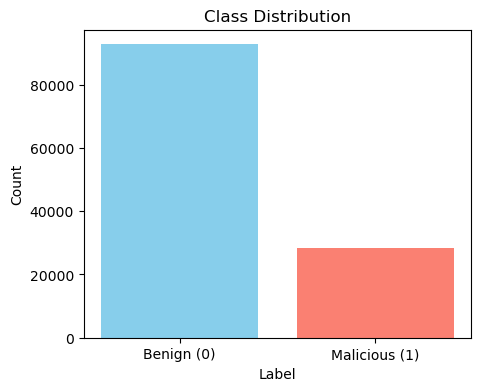

In [7]:
plt.figure(figsize=(5, 4))
counts = df['label'].value_counts()
plt.bar(counts.index, counts.values, color=['skyblue', 'salmon'])
plt.title("Class Distribution")
plt.xlabel("Label")
plt.ylabel("Count")
plt.xticks([0, 1], ['Benign (0)', 'Malicious (1)'])
plt.show()

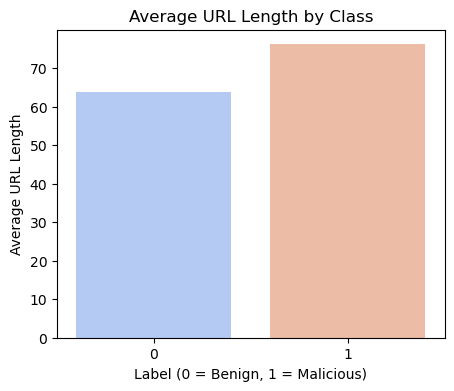

In [8]:
# Col URL length
df['url_length'] = df['domain'].apply(len)

# Grouping by label and calculating the average URL length
avg_len = df.groupby('label')['url_length'].mean().reset_index()

# Plotting average URL length for each class
plt.figure(figsize=(5,4))
sns.barplot(x='label', y='url_length', data=avg_len, palette='coolwarm')
plt.title("Average URL Length by Class")
plt.xlabel("Label (0 = Benign, 1 = Malicious)")
plt.ylabel("Average URL Length")
plt.show()


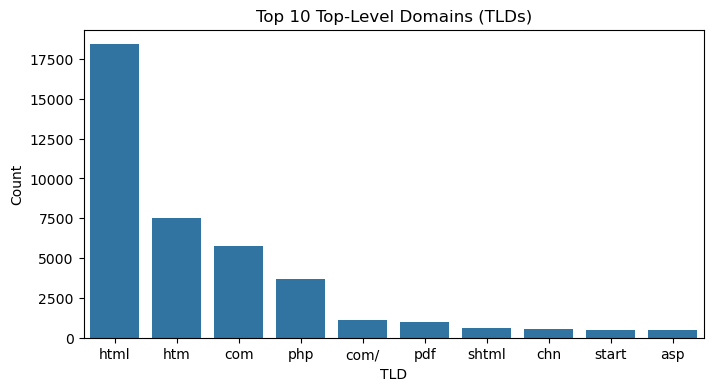

In [9]:
# Extract top-level domains
df['tld'] = df['domain'].apply(lambda x: x.split('.')[-1] if pd.notnull(x) else None)

# Plotting op 10 TLDs overall
top_tlds = df['tld'].value_counts().head(10)
plt.figure(figsize=(8,4))
sns.barplot(x=top_tlds.index, y=top_tlds.values)
plt.title("Top 10 Top-Level Domains (TLDs)")
plt.xlabel("TLD")
plt.ylabel("Count")
plt.show()

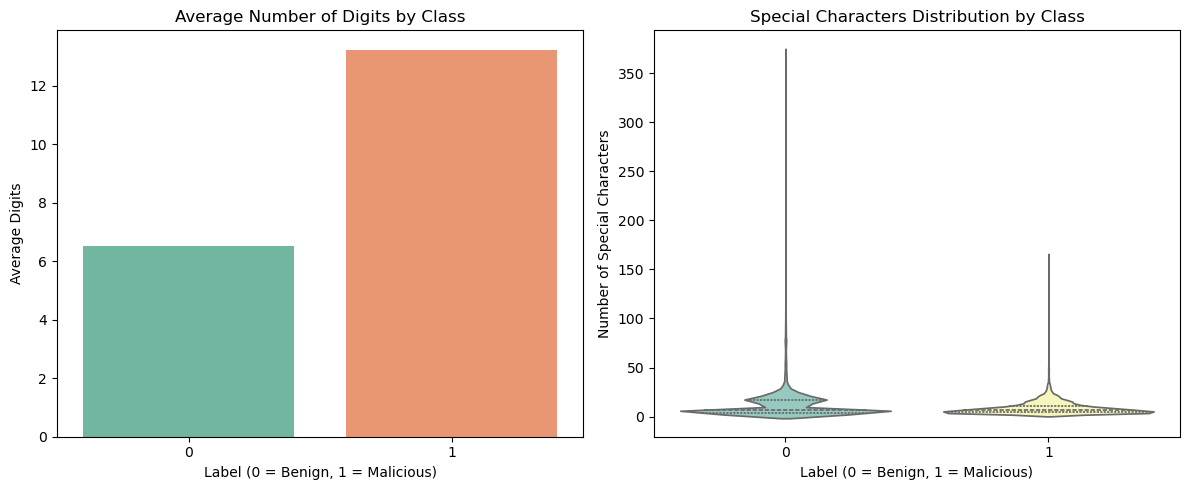

In [10]:
import re

# Count digits in each domain
df['num_digits'] = df['domain'].apply(lambda x: sum(c.isdigit() for c in x))

# Count special characters (non-alphanumeric)
df['num_special_chars'] = df['domain'].apply(lambda x: len(re.findall(r'[^a-zA-Z0-9]', x)))

fig, ax = plt.subplots(1, 2, figsize=(12,5))

# 1 Average digits count by class 
avg_digits = df.groupby('label')['num_digits'].mean().reset_index()
sns.barplot(x='label', y='num_digits', data=avg_digits, palette='Set2', ax=ax[0])
ax[0].set_title("Average Number of Digits by Class")
ax[0].set_xlabel("Label (0 = Benign, 1 = Malicious)")
ax[0].set_ylabel("Average Digits")

# 2 Distribution of special characters 
sns.violinplot(x='label', y='num_special_chars', data=df, palette='Set3', inner='quartile', ax=ax[1])
ax[1].set_title("Special Characters Distribution by Class")
ax[1].set_xlabel("Label (0 = Benign, 1 = Malicious)")
ax[1].set_ylabel("Number of Special Characters")

plt.tight_layout()
plt.show()


## Step 4: Defining functions for parsing the URL

In [11]:
SCHEME_RE = re.compile(r"^[a-zA-Z][a-zA-Z0-9+.-]*://")

def ensure_scheme(url: str) -> str:
    url = url.strip()
    if not SCHEME_RE.match(url):
        return "http://" + url
    return url

def to_ascii_host(host: str) -> str:
    # normalize IDN via IDNA; return original if fails
    if not host:
        return host
    try:
        # lower and normalize unicode
        host_norm = unicodedata.normalize("NFC", host.strip().lower())
        # encode to IDNA (punycode)
        labels = host_norm.split(".")
        ascii_labels = [idna.encode(lbl).decode("ascii") for lbl in labels if lbl]
        return ".".join(ascii_labels)
    except Exception:
        return host.strip().lower()

def safe_unquote(s: str) -> str:
    try:
        return unquote(s)
    except Exception:
        return s

def normalize_url(raw: str) -> str:
    s = str(raw).strip()
    s = ensure_scheme(s)
    # parse once to get parts
    p = urlparse(s)
    host = to_ascii_host(p.hostname or "")
    # rebuild minimal normalized form
    path = safe_unquote(p.path or "")
    query = safe_unquote(p.query or "")
    # strip fragments
    path = path.strip()
    query = query.strip()
    # collapse multiple slashes in path (not the scheme slashes)
    path = re.sub(r"/{2,}", "/", path)
    # lowercase scheme and host
    scheme = (p.scheme or "http").lower()
    netloc = host
    if p.port:
        netloc = f"{host}:{p.port}"
    # remove trailing slash if path is "/" only
    if path == "/":
        path = ""
    # rebuild
    base = f"{scheme}://{netloc}"
    if path:
        base += path if path.startswith("/") else ("/" + path)
    if query:
        base += "?" + query
    return base

def parse_url_components(url: str):
    # Assumes normalized URL with scheme
    p = urlparse(url)
    scheme = p.scheme or ""
    host = (p.hostname or "").lower()
    path = p.path or ""
    query = p.query or ""
    return scheme, host, path, query


## Step 5: Feature engineering for URLs

In [12]:
ETLD_RE = re.compile(r"([^.]+\.[^.]+)$")  # simple eTLD+1 heuristic; for production consider publicsuffix2

SUSPICIOUS_KEYWORDS = [
    "login","logon","verify","account","secure","update","billing","webscr",
    "session","confirm","password","reset","signin","bank","paypal","invoice",
    "support","limit","unlock","token"
]

FILE_EXTENSIONS = ["php","asp","aspx","jsp","html","htm","cgi"]

def shannon_entropy(s: str) -> float:
    if not s:
        return 0.0
    # count frequencies
    freq = {}
    for ch in s:
        freq[ch] = freq.get(ch, 0) + 1
    n = len(s)
    ent = 0.0
    for c in freq.values():
        p = c / n
        ent -= p * math.log2(p)
    return ent

def is_ip(host: str) -> bool:
    if not host:
        return False
    # IPv4 quick check
    if re.match(r"^\d{1,3}(\.\d{1,3}){3}$", host):
        parts = host.split(".")
        return all(0 <= int(x) <= 255 for x in parts)
    # IPv6 minimal check
    return ":" in host

def get_etld1(host: str) -> str:
    # naive fallback; for correctness use publicsuffixlist if allowed
    m = ETLD_RE.search(host)
    return m.group(1) if m else host

class URLFeatureExtractor(BaseEstimator, TransformerMixin):
    def __init__(self):
        pass

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        # X: array-like of raw domain/url strings
        feats = []
        for raw in X:
            raw = "" if pd.isna(raw) else str(raw)
            norm = normalize_url(raw)
            scheme, host, path, query = parse_url_components(norm)
            etld1 = get_etld1(host)
            subdomain = host[:-len(etld1)].rstrip(".") if host.endswith(etld1) and etld1 else ""
            sub_parts = [p for p in subdomain.split(".") if p]

            # base strings for stats
            whole = host + path + ("?" + query if query else "")

            # length features
            total_len = len(norm)
            host_len = len(host)
            path_len = len(path)
            query_len = len(query)

            # composition
            digits = sum(ch.isdigit() for ch in whole)
            alphas = sum(ch.isalpha() for ch in whole)
            specials = len(whole) - digits - alphas
            digit_ratio = digits / max(1, len(whole))
            alpha_ratio = alphas / max(1, len(whole))
            special_ratio = specials / max(1, len(whole))

            # special char counts
            cnt_dash = whole.count("-")
            cnt_underscore = whole.count("_")
            cnt_at = whole.count("@")
            cnt_pct = whole.count("%")
            cnt_dot = whole.count(".")
            cnt_slash = whole.count("/")

            # host structure
            n_subdomains = len(sub_parts)
            max_sub_len = max([len(s) for s in sub_parts], default=0)
            host_is_ip = int(is_ip(host))

            # path/query structure
            path_segs = [p for p in path.split("/") if p]
            n_path_segs = len(path_segs)
            params = [p for p in query.split("&") if p]
            n_params = len(params)
            max_token_len = max([len(tok) for tok in re.split(r"[/\-\._=&\?\+%]", whole) if tok], default=0)

            # file extension in path
            ext = ""
            if "." in path:
                ext = path.rsplit(".", 1)[-1].lower()
            ext_is_listed = int(ext in FILE_EXTENSIONS)

            # keyword flags
            lower_all = whole.lower()
            kw_flags = [int(k in lower_all) for k in SUSPICIOUS_KEYWORDS]

            # entropy
            ent_host = shannon_entropy(host)
            ent_path = shannon_entropy(path)

            # assemble feature vector
            row = [
                total_len, host_len, path_len, query_len,
                digits, alphas, specials, digit_ratio, alpha_ratio, special_ratio,
                cnt_dash, cnt_underscore, cnt_at, cnt_pct, cnt_dot, cnt_slash,
                n_subdomains, max_sub_len, host_is_ip,
                n_path_segs, n_params, max_token_len,
                ext_is_listed,
                ent_host, ent_path
            ] + kw_flags

            feats.append(row)

        feats = np.array(feats, dtype=float)
        return feats

# Define feature names for reference
feature_names = [
    "total_len","host_len","path_len","query_len",
    "digits","alphas","specials","digit_ratio","alpha_ratio","special_ratio",
    "cnt_dash","cnt_underscore","cnt_at","cnt_pct","cnt_dot","cnt_slash",
    "n_subdomains","max_sub_len","host_is_ip",
    "n_path_segs","n_params","max_token_len",
    "ext_is_listed",
    "ent_host","ent_path"
] + [f"kw_{k}" for k in SUSPICIOUS_KEYWORDS]
len(feature_names)


45

In [13]:
feat_groups = {
    "Lengths": ["total_len","host_len","path_len","query_len"],
    "Composition": ["digits","alphas","specials","digit_ratio","alpha_ratio","special_ratio"],
    "Special chars": ["cnt_dash","cnt_underscore","cnt_at","cnt_pct","cnt_dot","cnt_slash"],
    "Host structure": ["n_subdomains","max_sub_len","host_is_ip"],
    "Path/query": ["n_path_segs","n_params","max_token_len","ext_is_listed"],
    "Entropy": ["ent_host","ent_path"],
    "Keywords": [f"kw_{k}" for k in SUSPICIOUS_KEYWORDS],
}
pd.DataFrame([(k, ", ".join(v)) for k,v in feat_groups.items()], columns=["Group","Features"])


,Group,Features
0,Lengths,"total_len, host_len, path_len, query_len"
1,Composition,"digits, alphas, specials, digit_ratio, alpha_r..."
2,Special chars,"cnt_dash, cnt_underscore, cnt_at, cnt_pct, cnt..."
3,Host structure,"n_subdomains, max_sub_len, host_is_ip"
4,Path/query,"n_path_segs, n_params, max_token_len, ext_is_l..."
5,Entropy,"ent_host, ent_path"
6,Keywords,"kw_login, kw_logon, kw_verify, kw_account, kw_..."


In [14]:
from IPython.display import display

feat_table = pd.DataFrame([(k, ", ".join(v)) for k, v in feat_groups.items()],
                          columns=["Group","Features"])
display(feat_table)  

,Group,Features
0,Lengths,"total_len, host_len, path_len, query_len"
1,Composition,"digits, alphas, specials, digit_ratio, alpha_r..."
2,Special chars,"cnt_dash, cnt_underscore, cnt_at, cnt_pct, cnt..."
3,Host structure,"n_subdomains, max_sub_len, host_is_ip"
4,Path/query,"n_path_segs, n_params, max_token_len, ext_is_l..."
5,Entropy,"ent_host, ent_path"
6,Keywords,"kw_login, kw_logon, kw_verify, kw_account, kw_..."


## Step 6: Build X, y, groups

In [15]:
X_raw = df["domain"].astype(str).values
y = df["label"].values

# Precompute normalized URL and host for grouping
normed = [normalize_url(x) for x in X_raw]
hosts = [parse_url_components(x)[1] for x in normed]
groups = [get_etld1(h) for h in hosts]

extractor = URLFeatureExtractor()
X = extractor.transform(X_raw)

print(X.shape, y.shape)
pd.Series(groups).head()

(120990, 45) (120990,)


0    sprint.com
1      nasa.gov
2        web.de
3     wired.com
4    arnatt.com
dtype: object

## Step 7: Grouped and stratified splits (64/16/20)

In [16]:
unique_groups = pd.Series(groups).astype(str)
gtrain, gtest = train_test_split(unique_groups.unique(), test_size=0.2, random_state=42)

is_test = unique_groups.isin(set(gtest)).values
X_trainval, X_test = X[~is_test], X[is_test]
y_trainval, y_test = y[~is_test], y[is_test]

# Within trainval, stratified split
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.2, random_state=42, stratify=y_trainval
)

print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)
print("Pos rates:", y_train.mean(), y_val.mean(), y_test.mean())


Train: (73111, 45) Val: (18278, 45) Test: (29601, 45)
Pos rates: 0.24126328459465743 0.2412736623262939 0.21151312455660282


## Step 8: Applying algorithms

### (1) Logistic Regression

In [17]:
# Jupyter cell: Logistic Regression pipeline with scaling
logreg_clf = Pipeline(steps=[
    ("scaler", StandardScaler(with_mean=True, with_std=True)),
    ("clf", LogisticRegression(max_iter=2000, class_weight="balanced", n_jobs=-1))
])

logreg_clf.fit(X_train, y_train)

# Validation metrics
val_proba_lr = logreg_clf.predict_proba(X_val)[:, 1]
val_pred_lr = (val_proba_lr >= 0.5).astype(int)
val_roc_lr = roc_auc_score(y_val, val_proba_lr)
val_pr_lr = average_precision_score(y_val, val_proba_lr)
print("LogReg Val ROC-AUC:", val_roc_lr)
print("LogReg Val PR-AUC:", val_pr_lr)
print(classification_report(y_val, val_pred_lr, digits=4))


LogReg Val ROC-AUC: 0.9185648030965102
LogReg Val PR-AUC: 0.84344682228558
              precision    recall  f1-score   support

           0     0.9317    0.8872    0.9089     13868
           1     0.6916    0.7955    0.7399      4410

    accuracy                         0.8651     18278
   macro avg     0.8117    0.8413    0.8244     18278
weighted avg     0.8738    0.8651    0.8681     18278



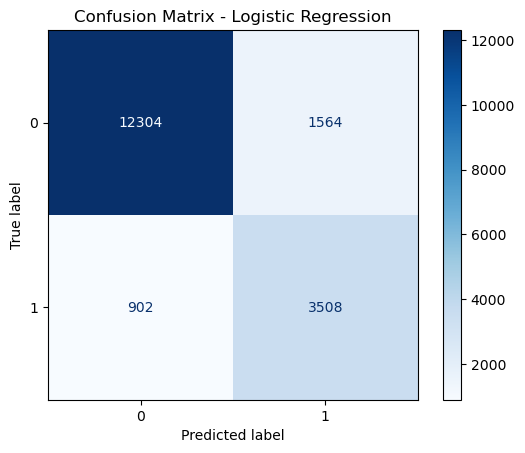

In [18]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_val, val_pred_lr)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()


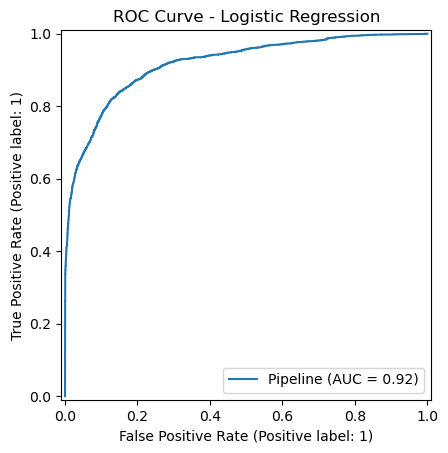

In [19]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(logreg_clf, X_val, y_val)
plt.title("ROC Curve - Logistic Regression")
plt.show()


In [20]:
acc_lr = accuracy_score(y_val, val_pred_lr)
print(f"Logistic Regression Accuracy: {acc_lr:.4f}")

Logistic Regression Accuracy: 0.8651


### (2) Random Forest

100 trees → Accuracy: 0.9602, ROC-AUC: 0.9903
200 trees → Accuracy: 0.9611, ROC-AUC: 0.9905
300 trees → Accuracy: 0.9615, ROC-AUC: 0.9906
400 trees → Accuracy: 0.9611, ROC-AUC: 0.9907
500 trees → Accuracy: 0.9613, ROC-AUC: 0.9907
600 trees → Accuracy: 0.9612, ROC-AUC: 0.9907


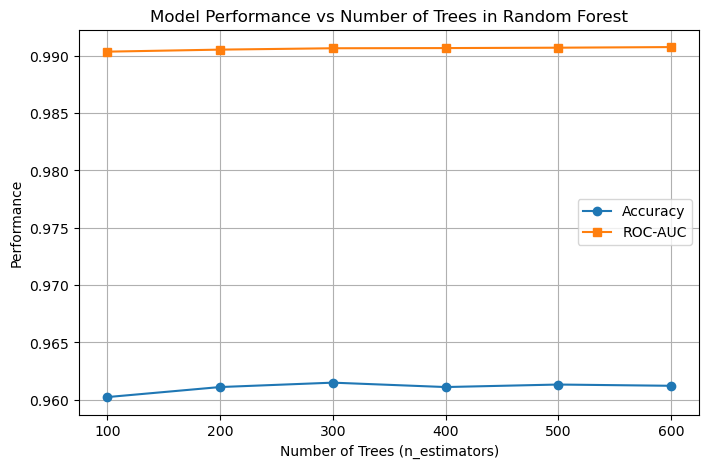


Best n_estimators = 600 (ROC-AUC = 0.9907)


In [21]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score
import matplotlib.pyplot as plt

# Try different values of n_estimators
n_values = [100, 200, 300, 400, 500, 600]
accuracies = []
roc_aucs = []

for n in n_values:
    rf = RandomForestClassifier(
        n_estimators=n,
        class_weight='balanced_subsample',
        random_state=42,
        n_jobs=-1
    )
    
    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_val)
    y_proba = rf.predict_proba(X_val)[:, 1]
    
    acc = accuracy_score(y_val, y_pred)
    roc_auc = roc_auc_score(y_val, y_proba)
    
    accuracies.append(acc)
    roc_aucs.append(roc_auc)
    
    print(f"{n} trees → Accuracy: {acc:.4f}, ROC-AUC: {roc_auc:.4f}")

# Plot performance vs number of trees
plt.figure(figsize=(8,5))
plt.plot(n_values, accuracies, marker='o', label="Accuracy")
plt.plot(n_values, roc_aucs, marker='s', label="ROC-AUC")
plt.xlabel("Number of Trees (n_estimators)")
plt.ylabel("Performance")
plt.title("Model Performance vs Number of Trees in Random Forest")
plt.legend()
plt.grid(True)
plt.show()

# Print best n_estimators based on ROC-AUC
best_index = roc_aucs.index(max(roc_aucs))
best_n = n_values[best_index]
print(f"\nBest n_estimators = {best_n} (ROC-AUC = {roc_aucs[best_index]:.4f})")

In [22]:
# On tabular features
rf_clf = RandomForestClassifier(
    n_estimators=400,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    class_weight="balanced_subsample",
    n_jobs=-1,
    random_state=42
)

rf_clf.fit(X_train, y_train)

val_proba_rf = rf_clf.predict_proba(X_val)[:, 1]
val_pred_rf = (val_proba_rf >= 0.5).astype(int)
val_roc_rf = roc_auc_score(y_val, val_proba_rf)
val_pr_rf = average_precision_score(y_val, val_proba_rf)
print("RF Val ROC-AUC:", val_roc_rf)
print("RF Val PR-AUC:", val_pr_rf)
print(classification_report(y_val, val_pred_rf, digits=4))

RF Val ROC-AUC: 0.9906617593677217
RF Val PR-AUC: 0.9762076088535171
              precision    recall  f1-score   support

           0     0.9706    0.9786    0.9746     13868
           1     0.9309    0.9068    0.9187      4410

    accuracy                         0.9613     18278
   macro avg     0.9507    0.9427    0.9466     18278
weighted avg     0.9610    0.9613    0.9611     18278



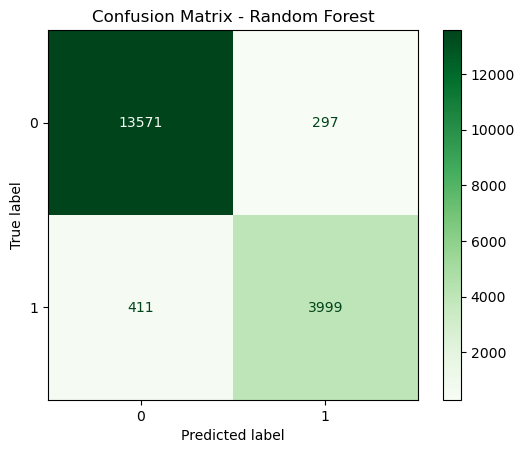

In [23]:
# Confusion Matrix
cm = confusion_matrix(y_val, val_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Greens")
plt.title("Confusion Matrix - Random Forest")
plt.show()

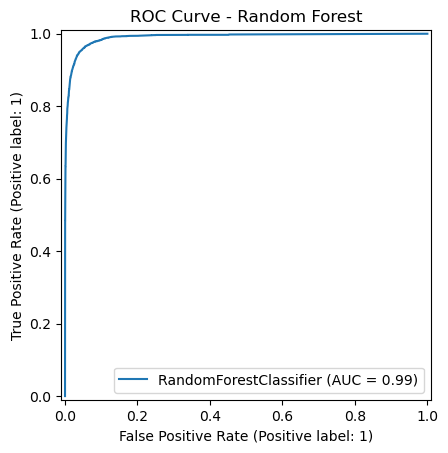

In [24]:
# ROC Curve
RocCurveDisplay.from_estimator(rf_clf, X_val, y_val)
plt.title("ROC Curve - Random Forest")
plt.show()

In [25]:
acc_rf = accuracy_score(y_val, val_pred_rf)
print(f"Random Forest Accuracy:       {acc_rf:.4f}")

Random Forest Accuracy:       0.9613


### (3) Lightgbm

In [26]:
#Base LightGBM model (Default parameters)
lgb_default = lgb.LGBMClassifier(random_state=42)
lgb_default.fit(X_train, y_train)

# Predictions
y_pred_default = lgb_default.predict(X_val)
y_proba_default = lgb_default.predict_proba(X_val)[:, 1]

# Evaluate base model
acc_default = accuracy_score(y_val, y_pred_default)
roc_default = roc_auc_score(y_val, y_proba_default)

print("Default LightGBM Accuracy:", acc_default)
print("Default LightGBM ROC-AUC:", roc_default)

[LightGBM] [Info] Number of positive: 17639, number of negative: 55472
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.017495 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2967
[LightGBM] [Info] Number of data points in the train set: 73111, number of used features: 41
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.241263 -> initscore=-1.145766
[LightGBM] [Info] Start training from score -1.145766
Default LightGBM Accuracy: 0.9569974833132728
Default LightGBM ROC-AUC: 0.9902798053169927


In [27]:
val_pred_lgb_default = lgb_default.predict(X_val)
acc_lgb_default = accuracy_score(y_val, val_pred_lgb_default)
print(f"Default LightGBM Accuracy:    {acc_lgb_default:.4f}")

Default LightGBM Accuracy:    0.9570


#### Hyperparameter Tunning ####

In [28]:
#RandomizedSearchCV for tuning
lgbm = lgb.LGBMClassifier(random_state=42)

param_dist = {
    'n_estimators': [100, 200, 300, 400, 500],
    'learning_rate': np.linspace(0.01, 0.3, 10),
    'max_depth': [-1, 3, 5, 7, 9],
    'num_leaves': [15, 31, 63, 127],
    'subsample': np.linspace(0.6, 1.0, 5),
    'colsample_bytree': np.linspace(0.6, 1.0, 5),
    'reg_lambda': [0, 0.1, 0.5, 1.0],
}

In [29]:
random_search = RandomizedSearchCV(
    estimator=lgbm,
    param_distributions=param_dist,
    n_iter=25,
    scoring='accuracy',
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

Fitting 3 folds for each of 25 candidates, totalling 75 fits
[LightGBM] [Info] Number of positive: 17639, number of negative: 55472
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.018740 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2967
[LightGBM] [Info] Number of data points in the train set: 73111, number of used features: 41
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.241263 -> initscore=-1.145766
[LightGBM] [Info] Start training from score -1.145766


RandomizedSearchCV(cv=3, estimator=LGBMClassifier(random_state=42), n_iter=25,
                   n_jobs=-1,
                   param_distributions={'colsample_bytree': array([0.6, 0.7, 0.8, 0.9, 1. ]),
                                        'learning_rate': array([0.01      , 0.04222222, 0.07444444, 0.10666667, 0.13888889,
       0.17111111, 0.20333333, 0.23555556, 0.26777778, 0.3       ]),
                                        'max_depth': [-1, 3, 5, 7, 9],
                                        'n_estimators': [100, 200, 300, 400,
                                                         500],
                                        'num_leaves': [15, 31, 63, 127],
                                        'reg_lambda': [0, 0.1, 0.5, 1.0],
                                        'subsample': array([0.6, 0.7, 0.8, 0.9, 1. ])},
                   random_state=42, scoring='accuracy', verbose=1)

In [30]:
#Best results
print("\nBest Parameters:", random_search.best_params_)
print("Best CV Accuracy:", random_search.best_score_)


Best Parameters: {'subsample': 0.7, 'reg_lambda': 0.1, 'num_leaves': 127, 'n_estimators': 500, 'max_depth': -1, 'learning_rate': 0.042222222222222223, 'colsample_bytree': 1.0}
Best CV Accuracy: 0.9640272814835092


In [31]:
best_params = random_search.best_params_

lgb_tuned = lgb.LGBMClassifier(**best_params, random_state=42)
lgb_tuned.fit(X_train, y_train)

# Predictions & probabilities
y_pred_tuned = lgb_tuned.predict(X_val)
y_proba_tuned = lgb_tuned.predict_proba(X_val)[:, 1]

# Evaluate tuned model
acc_tuned = accuracy_score(y_val, y_pred_tuned)
roc_tuned = roc_auc_score(y_val, y_proba_tuned)

print("\nTuned LightGBM Accuracy:", acc_tuned)
print("Tuned LightGBM ROC-AUC:", roc_tuned)

[LightGBM] [Info] Number of positive: 17639, number of negative: 55472
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.016868 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2967
[LightGBM] [Info] Number of data points in the train set: 73111, number of used features: 41
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.241263 -> initscore=-1.145766
[LightGBM] [Info] Start training from score -1.145766

Tuned LightGBM Accuracy: 0.9660247291826239
Tuned LightGBM ROC-AUC: 0.9935302858764888



Classification Report:
              precision    recall  f1-score   support

           0     0.9747    0.9807    0.9777     13868
           1     0.9380    0.9200    0.9289      4410

    accuracy                         0.9660     18278
   macro avg     0.9564    0.9503    0.9533     18278
weighted avg     0.9659    0.9660    0.9659     18278



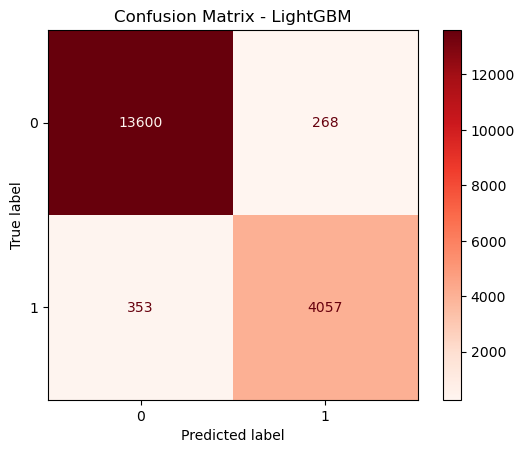

In [32]:
# Convert probabilities to binary predictions
val_pred_lgb = (y_proba_tuned >= 0.5).astype(int)

# Classification Report
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

print("\nClassification Report:")
print(classification_report(y_val, val_pred_lgb, digits=4))

# Confusion Matrix
cm = confusion_matrix(y_val, val_pred_lgb)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Reds")
plt.title("Confusion Matrix - LightGBM")
plt.show()


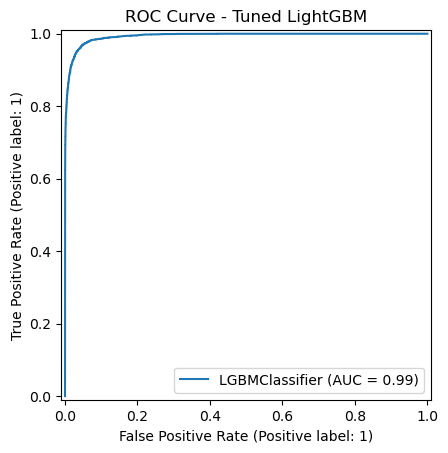

In [33]:
# ROC curve
RocCurveDisplay.from_estimator(lgb_tuned, X_val, y_val)
plt.title("ROC Curve - Tuned LightGBM")
plt.show()

In [34]:
val_pred_lgb_tuned = lgb_tuned.predict(X_val)

acc_lgb_tuned = accuracy_score(y_val, val_pred_lgb_tuned)
print(f"Tuned LightGBM Accuracy: {acc_lgb_tuned:.4f}")

Tuned LightGBM Accuracy: 0.9660


#### Compare accuracy between models

In [35]:
print("🔹 Model Performance Comparison:")
print(f"Logistic Regression Accuracy: {acc_lr:.4f}")
print(f"Random Forest Accuracy:       {acc_rf:.4f}")
print(f"Default LightGBM Accuracy:    {acc_default:.4f}")
print(f"Tuned LightGBM Accuracy:      {acc_lgb_tuned:.4f}")

🔹 Model Performance Comparison:
Logistic Regression Accuracy: 0.8651
Random Forest Accuracy:       0.9613
Default LightGBM Accuracy:    0.9570
Tuned LightGBM Accuracy:      0.9660


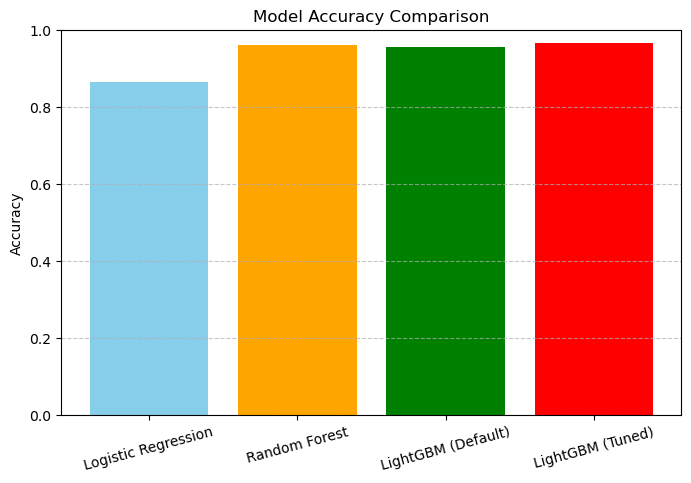

In [36]:
import matplotlib.pyplot as plt

models = ['Logistic Regression', 'Random Forest', 'LightGBM (Default)', 'LightGBM (Tuned)']
accuracies = [acc_lr, acc_rf, acc_default, acc_lgb_tuned]

plt.figure(figsize=(8,5))
plt.bar(models, accuracies, color=['skyblue','orange','green','red'])
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
plt.ylim(0,1)
plt.xticks(rotation=15)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## Step 9: Select best model, calibrate, and test

In [37]:
# Predictions before calibration
y_proba_tuned = lgb_tuned.predict_proba(X_val)[:, 1]
y_pred_tuned = (y_proba_tuned >= 0.5).astype(int)

#valuate before calibration
from sklearn.metrics import accuracy_score, roc_auc_score, brier_score_loss

acc_before = accuracy_score(y_val, y_pred_tuned)
roc_before = roc_auc_score(y_val, y_proba_tuned)
brier_before = brier_score_loss(y_val, y_proba_tuned)

print("Before Calibration:")
print("Accuracy:", acc_before)
print("ROC-AUC:", roc_before)
print("Brier Score:", brier_before)

Before Calibration:
Accuracy: 0.9660247291826239
ROC-AUC: 0.9935302858764888
Brier Score: 0.025180948832343487


In [38]:
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import brier_score_loss, accuracy_score, roc_auc_score

# 1️ Fit your tuned LightGBM again (to be sure)
lgb_tuned.fit(X_train, y_train)

# 2️ Apply calibration (sigmoid = Platt scaling)
calibrated_lgb = CalibratedClassifierCV(lgb_tuned, method='sigmoid', cv=3)
calibrated_lgb.fit(X_train, y_train)

# 3️ Predictions after calibration
y_proba_calibrated = calibrated_lgb.predict_proba(X_val)[:, 1]
y_pred_calibrated = (y_proba_calibrated >= 0.5).astype(int)

# 4️ Evaluate calibrated model
acc_calibrated = accuracy_score(y_val, y_pred_calibrated)
roc_calibrated = roc_auc_score(y_val, y_proba_calibrated)
brier = brier_score_loss(y_val, y_proba_calibrated)

print("Calibrated LightGBM Accuracy:", acc_calibrated)
print("Calibrated LightGBM ROC-AUC:", roc_calibrated)
print("Brier Score (lower = better):", brier)

[LightGBM] [Info] Number of positive: 17639, number of negative: 55472
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.016437 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2967
[LightGBM] [Info] Number of data points in the train set: 73111, number of used features: 41
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.241263 -> initscore=-1.145766
[LightGBM] [Info] Start training from score -1.145766
[LightGBM] [Info] Number of positive: 11759, number of negative: 36981
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.011544 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2844
[LightGBM] [Info] Number of data points in the train set: 48740, number of used features: 41
[LightGBM] [Info] 

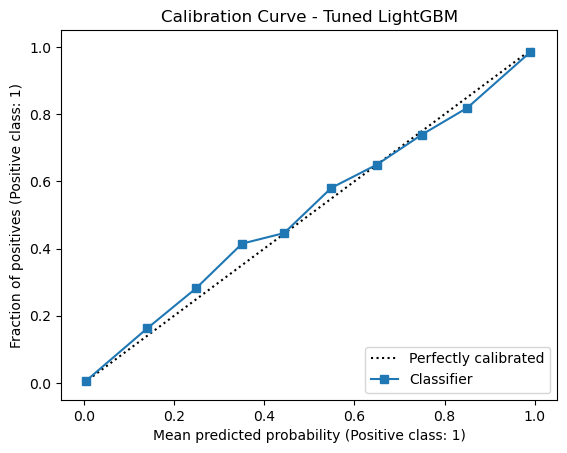

Brier Score (before calibration): 0.025180948832343487


In [39]:
from sklearn.calibration import CalibrationDisplay
from sklearn.metrics import brier_score_loss

# Predicted probabilities from tuned LightGBM
y_proba_tuned = lgb_tuned.predict_proba(X_val)[:, 1]

# Calibration curve
CalibrationDisplay.from_predictions(y_val, y_proba_tuned, n_bins=10)
plt.title("Calibration Curve - Tuned LightGBM")
plt.show()

# Brier score (lower is better)
brier = brier_score_loss(y_val, y_proba_tuned)
print("Brier Score (before calibration):", brier)

## Step 9: Optimize F1 threshold and apply to test

In [40]:
val_proba_map = {
    "logreg": val_proba_lr,   # Logistic Regression
    "rf": val_proba_rf,       # Random Forest
    "lgb": y_proba_tuned      # LightGBM (Tuned)
}

#Choosing best model manually, since we have tested
best_model_name = "lgb"  

#Getting validation probabilities for the best model
val_proba_best = val_proba_map[best_model_name]


In [41]:
# Precision, Recall, and Thresholds
prec, rec, thr = precision_recall_curve(y_val, val_proba_best)

# F1-score for each threshold
f1s = 2 * (prec * rec) / np.maximum(prec + rec, 1e-12)

# Best threshold (highest F1)
best_idx = np.nanargmax(f1s)
best_thr = thr[max(0, best_idx-1)] if best_idx < len(thr) else 0.5

print("Best validation F1:", np.nanmax(f1s))
print("Best threshold value:", best_thr)

Best validation F1: 0.929612756264237
Best threshold value: 0.463617317373304


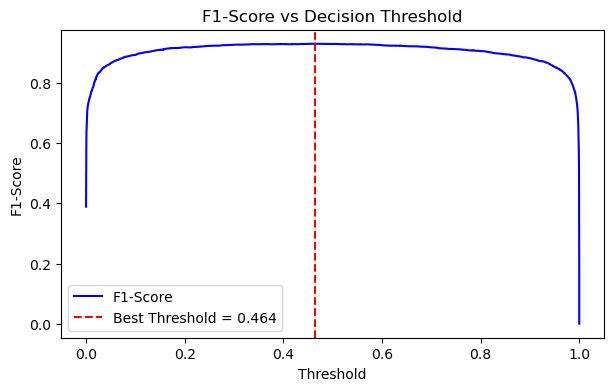

In [42]:
plt.figure(figsize=(7, 4))
plt.plot(thr, f1s[:-1], label='F1-Score', color='blue')
plt.axvline(best_thr, color='red', linestyle='--', label=f'Best Threshold = {best_thr:.3f}')
plt.xlabel("Threshold")
plt.ylabel("F1-Score")
plt.title("F1-Score vs Decision Threshold")
plt.legend()
plt.show()

In [43]:
# Calibrated probabilities on test data
test_proba = calibrated_lgb.predict_proba(X_test)[:, 1]

# Apply best threshold
test_pred_thr = (test_proba >= best_thr).astype(int)

# Evaluating on test data
p, r, f1, _ = precision_recall_fscore_support(y_test, test_pred_thr, average="binary")

print(f"Test Results at threshold {best_thr:.3f}:")
print(f"Precision: {p:.4f}")
print(f"Recall: {r:.4f}")
print(f"F1-Score: {f1:.4f}")


Test Results at threshold 0.464:
Precision: 0.7931
Recall: 0.9102
F1-Score: 0.8476


## Step 11: Build and save best-model pipeline

In [82]:
# Feature extractor assuming URLFeatureExtractor already exists
class URLVectorizer(BaseEstimator, TransformerMixin):
    def __init__(self):
        self._fe = URLFeatureExtractor()  # custom extractor

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        return self._fe.transform(X)

In [83]:
# Using tuned LightGBM which is the best model
best_model_name = "lgb"
best_model = lgb_tuned  # Tuned LightGBM

In [84]:
# Calibrating the model (already tuned)
calibrated_best = CalibratedClassifierCV(best_model, method='sigmoid', cv=3)
calibrated_best.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 11759, number of negative: 36981
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.015783 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2844
[LightGBM] [Info] Number of data points in the train set: 48740, number of used features: 41
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.241260 -> initscore=-1.145785
[LightGBM] [Info] Start training from score -1.145785
[LightGBM] [Info] Number of positive: 11760, number of negative: 36981
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.014265 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2846
[LightGBM] [Info] Number of data points in the train set: 48741, number of used features: 41
[LightGBM] [Info] 

CalibratedClassifierCV(cv=3,
                       estimator=LGBMClassifier(learning_rate=0.042222222222222223,
                                                n_estimators=500,
                                                num_leaves=127, random_state=42,
                                                reg_lambda=0.1, subsample=0.7))

In [85]:
# Building production pipeline
steps = [
    ("vec", URLVectorizer()),  # URL → numeric features
    ("clf", calibrated_best)   # calibrated LightGBM
]
prod_pipeline = Pipeline(steps)

# Fitting pipeline on all available data (train + val)
prod_pipeline.fit(df["domain"].astype(str).values, df["label"].values)

[LightGBM] [Info] Number of positive: 18874, number of negative: 61786
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.022573 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3040
[LightGBM] [Info] Number of data points in the train set: 80660, number of used features: 41
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.233995 -> initscore=-1.185891
[LightGBM] [Info] Start training from score -1.185891
[LightGBM] [Info] Number of positive: 18873, number of negative: 61787
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.045708 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2998
[LightGBM] [Info] Number of data points in the train set: 80660, number of used features: 41
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.233982 -> initscore=-1.185961
[L

Pipeline(steps=[('vec', URLVectorizer()),
                ('clf',
                 CalibratedClassifierCV(cv=3,
                                        estimator=LGBMClassifier(learning_rate=0.042222222222222223,
                                                                 n_estimators=500,
                                                                 num_leaves=127,
                                                                 random_state=42,
                                                                 reg_lambda=0.1,
                                                                 subsample=0.7)))])

In [86]:
# Persist artifacts
ARTIFACT_DIR = "artifacts"
os.makedirs(ARTIFACT_DIR, exist_ok=True)
PIPELINE_PATH = os.path.join(ARTIFACT_DIR, "prod_pipeline.joblib")
joblib.dump(prod_pipeline, PIPELINE_PATH)

print("Production pipeline saved at:", PIPELINE_PATH)


Production pipeline saved at: artifacts\prod_pipeline.joblib


In [87]:
BEST_THRESHOLD = 0.4636   # from threshold tuning step

def predict_url(urls, pipeline=None):
    if pipeline is None:
        pipeline = joblib.load(PIPELINE_PATH)
    if isinstance(urls, str):
        urls = [urls]
    proba = pipeline.predict_proba(urls)[:, 1]
    preds = (proba >= BEST_THRESHOLD).astype(int)
    return list(zip(urls, proba, preds))


In [91]:
from sklearn.inspection import permutation_importance
import pandas as pd
import matplotlib.pyplot as plt

# Assumes:
# - prodpipeline is the fitted Pipeline( vec=URLVectorizer(), clf=CalibratedClassifierCV(LGBMClassifier(...)) )
# - X_val (raw URLs) and y_val exist from your split
fn = prod_pipeline.named_steps['vec'].feature_names

r = permutation_importance(
    prod_pipeline, X_val, y_val,
    n_repeats=10, random_state=42, scoring='roc_auc'
)

perm_df = pd.DataFrame({
    'feature': fn,
    'importance_mean': r.importances_mean,
    'importance_std': r.importances_std
}).sort_values('importance_mean', ascending=False)

display(perm_df.head(30))

plt.figure(figsize=(8,6))
plt.barh(perm_df.head(20)['feature'][::-1], perm_df.head(20)['importance_mean'][::-1], color="#f28e2b")
plt.xlabel("Permutation importance (Δ ROC-AUC)")
plt.ylabel("Feature")
plt.title("Permutation Importance (full calibrated pipeline)")
plt.tight_layout()
plt.show()


AttributeError: 'URLVectorizer' object has no attribute 'feature_names'

In [62]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Assumes:
# - pipe is fitted
# - pipe.named_steps['clf'] is CalibratedClassifierCV wrapping an LGBMClassifier
# - pipe.named_steps['vec'].featurenames gives feature names

calib = prod_pipeline.named_steps['clf']
lgb_est = calib.estimator  # LGBMClassifier
feature_names = prod_pipeline.named_steps['vec'].feature_names

gain_importance = lgb_est.booster_.feature_importance(importance_type='gain')
imp_df = pd.DataFrame({'feature': feature_names, 'gain': gain_importance}) \
           .sort_values('gain', ascending=False)

# Show numeric top features
display(imp_df.head(30))

# Plot top 20
topk = 20
plt.figure(figsize=(8, 6))
plt.barh(imp_df.head(topk)['feature'][::-1], imp_df.head(topk)['gain'][::-1], color="#4e79a7")
plt.title("LightGBM Feature Importance (gain)")
plt.xlabel("Total gain")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


AttributeError: 'URLVectorizer' object has no attribute 'feature_names'

In [63]:
# Quick test

samples = [
    "paypal.us.cgi.bin.webscr.cmd.login.webapps.mpp.home.billing.actiwe.home.45353445342342.mygrfenhostingsupport.com/6cc5ec611ea...",
    "https://stackoverflow.com/questions/92082/add-a-column-with-a-default-value-to-an-existing-table-in-sql-server"
]
results = predict_url(samples)

for u, p, pred in results:
    label = "MALICIOUS" if pred == 1 else "BENIGN"
    print(f"{u[:80]}... → Prob: {p:.4f}, Predicted: {label}")

paypal.us.cgi.bin.webscr.cmd.login.webapps.mpp.home.billing.actiwe.home.45353445... → Prob: 0.9843, Predicted: MALICIOUS
https://stackoverflow.com/questions/92082/add-a-column-with-a-default-value-to-a... → Prob: 0.0133, Predicted: BENIGN


In [64]:
pipeline = joblib.load("artifacts/prod_pipeline.joblib")

test_urls = [
    "https://paypal-update-login.com/security",
    "https://www.github.com/"
]

probs = pipeline.predict_proba(test_urls)[:, 1]
preds = (probs >= 0.738).astype(int)

for url, prob, pred in zip(test_urls, probs, preds):
    print(f"{url} → Prob: {prob:.4f}, Predicted: {'MALICIOUS' if pred == 1 else 'BENIGN'}")


https://paypal-update-login.com/security → Prob: 0.9843, Predicted: MALICIOUS
https://www.github.com/ → Prob: 0.3572, Predicted: BENIGN
